In [1]:
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, vertcross, CoordPair, to_np

filename = "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00"

REMOVE_FIRST_KM = 60.0
END_CUT_KM = 40.0

cross_start = CoordPair(lat=38.2617, lon=-96.4922)
cross_end   = CoordPair(lat=39.4597, lon=-94.5786)

ncfile = Dataset(filename)

theta = getvar(ncfile, "th")
pres  = getvar(ncfile, "pressure")

theta_cs_raw = vertcross(
    theta, pres,
    wrfin=ncfile,
    start_point=cross_start,
    end_point=cross_end,
    latlon=True,
    meta=True
)

coords = to_np(theta_cs_raw.coords["xy_loc"])

lats = np.array([p.lat for p in coords], dtype=float)
lons = np.array([p.lon for p in coords], dtype=float)

R = 6371.0
dist_km = np.zeros(len(lats), dtype=float)

for i in range(1, len(lats)):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lats[i - 1], lons[i - 1], lats[i], lons[i]]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )

    dist_km[i] = dist_km[i - 1] + 2.0 * R * np.arcsin(np.sqrt(a))

trim_end_dist = dist_km[-1] - END_CUT_KM

trim_start_lat = np.interp(REMOVE_FIRST_KM, dist_km, lats)
trim_start_lon = np.interp(REMOVE_FIRST_KM, dist_km, lons)

trim_end_lat = np.interp(trim_end_dist, dist_km, lats)
trim_end_lon = np.interp(trim_end_dist, dist_km, lons)

print("Original cross-section start:")
print(f"lat = {cross_start.lat:.6f}, lon = {cross_start.lon:.6f}")

print("\nOriginal cross-section end:")
print(f"lat = {cross_end.lat:.6f}, lon = {cross_end.lon:.6f}")

print("\nPlotted cross-section start after removing first 60 km:")
print(f"lat = {trim_start_lat:.6f}, lon = {trim_start_lon:.6f}")

print("\nPlotted cross-section end after removing last 40 km:")
print(f"lat = {trim_end_lat:.6f}, lon = {trim_end_lon:.6f}")

print("\nOriginal transect length:")
print(f"{dist_km[-1]:.2f} km")

print("\nPlotted transect length:")
print(f"{trim_end_dist - REMOVE_FIRST_KM:.2f} km")

ncfile.close()

Original cross-section start:
lat = 38.261700, lon = -96.492200

Original cross-section end:
lat = 39.459700, lon = -94.578600

Plotted cross-section start after removing first 60 km:
lat = 38.600428, lon = -95.961143

Plotted cross-section end after removing last 40 km:
lat = 39.238070, lon = -94.943502

Original transect length:
213.04 km

Plotted transect length:
113.04 km


Shared w color scale: min=-1.650 m/s, max=1.650 m/s using combined plotted-time values.


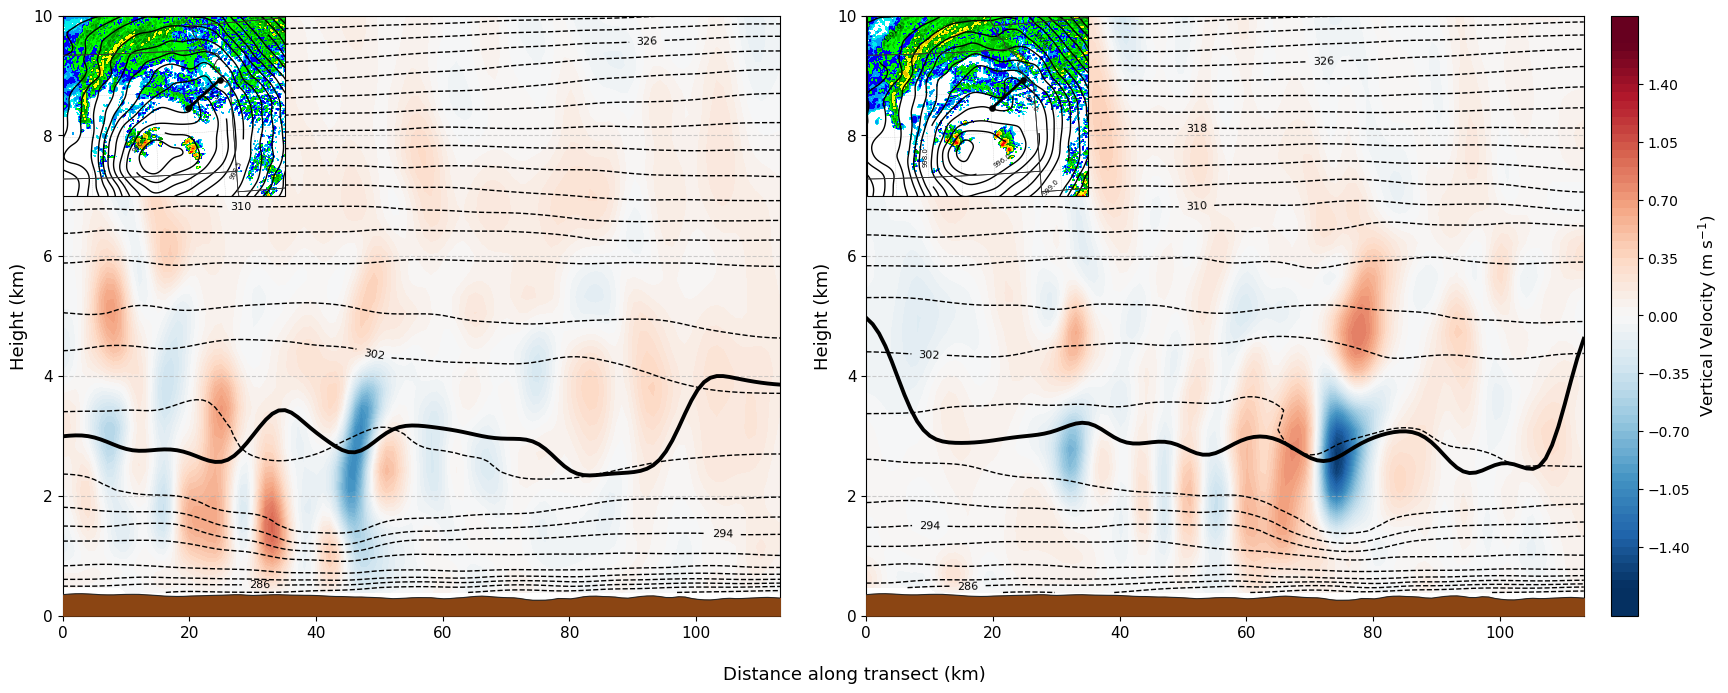

2200 UTC:
  File: /glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00
  Actual cross-section start: lat=38.604565, lon=-95.963287
  Actual cross-section end:   lat=39.238140, lon=-94.937866
  Actual transect length: 113.28 km
2230 UTC:
  File: /glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00
  Actual cross-section start: lat=38.604565, lon=-95.963287
  Actual cross-section end:   lat=39.238140, lon=-94.937866
  Actual transect length: 113.28 km
Done: publication-quality 1 x 2 subplot created.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.transforms import Bbox
from netCDF4 import Dataset
from wrf import (
    getvar, to_np, vertcross, interpline, CoordPair,
    latlon_coords, get_cartopy
)
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import warnings

import cartopy.crs as crs
from cartopy.feature import STATES, BORDERS
from metpy.plots import ctables


MIN_CL_Z_KM = 2.0
MAX_CL_Z_KM = 8.0

C = 15.0
DIR_DEG = 210.0

W_STEP = 0.05

SIG_TH = 3
SIG_W  = 1.5
SIG_UV = 0.3
SIG_Z  = 0.2

CRIT_SMOOTH_SIG = 3.0
SLP_SMOOTH_SIG = 15.0

MAP_LON_MIN = -99.8
MAP_LON_MAX = -93.2
MAP_LAT_MIN = 36.6
MAP_LAT_MAX = 40.7

cross_start = CoordPair(lat=38.600428, lon=-95.961143)
cross_end   = CoordPair(lat=39.238070, lon=-94.943502)

FILES = [
    {
        "label": "2200 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00",
    },
    {
        "label": "2230 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00",
    },
]


def fill_small_nan_gaps(y, max_gap=3):
    y2 = y.copy()
    n = len(y2)
    isnan = ~np.isfinite(y2)
    i = 0

    while i < n:
        if not isnan[i]:
            i += 1
            continue

        start = i

        while i < n and isnan[i]:
            i += 1

        end = i
        gap_len = end - start
        left = start - 1
        right = end

        if (
            gap_len <= max_gap
            and left >= 0
            and right < n
            and np.isfinite(y2[left])
            and np.isfinite(y2[right])
        ):
            y2[start:end] = np.interp(
                np.arange(start, end),
                [left, right],
                [y2[left], y2[right]]
            )

    return y2


def smooth_valid_segments(y, sigma=3.0, min_points=5):
    y_smooth = y.copy()
    valid = np.isfinite(y_smooth)
    n = len(y_smooth)
    i = 0

    while i < n:
        if not valid[i]:
            i += 1
            continue

        start = i

        while i < n and valid[i]:
            i += 1

        end = i

        if (end - start) >= min_points:
            y_smooth[start:end] = gaussian_filter1d(
                y_smooth[start:end],
                sigma=sigma,
                mode="nearest"
            )

    return y_smooth


def process_file(filename, label):
    ncfile = Dataset(filename)

    ter   = getvar(ncfile, "ter")
    theta = getvar(ncfile, "th")
    pres  = getvar(ncfile, "pressure")
    w     = getvar(ncfile, "wa")
    z     = getvar(ncfile, "z")
    u     = getvar(ncfile, "ua")
    v     = getvar(ncfile, "va")

    mdbz = getvar(ncfile, "mdbz")
    slp  = getvar(ncfile, "slp")

    theta_cs_raw = vertcross(
        theta, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    w_cs_raw = vertcross(
        w, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    u_cs_raw = vertcross(
        u, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    v_cs_raw = vertcross(
        v, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    z_cs_raw = vertcross(
        z, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    theta_cs = gaussian_filter1d(to_np(theta_cs_raw), sigma=SIG_TH, axis=-1)
    w_cs     = gaussian_filter1d(to_np(w_cs_raw),     sigma=SIG_W,  axis=-1)
    u_cs     = gaussian_filter1d(to_np(u_cs_raw),     sigma=SIG_UV, axis=-1)
    v_cs     = gaussian_filter1d(to_np(v_cs_raw),     sigma=SIG_UV, axis=-1)
    z_cs     = gaussian_filter1d(to_np(z_cs_raw),     sigma=SIG_Z,  axis=-1)

    theta_cs = np.ma.masked_invalid(theta_cs)
    w_cs     = np.ma.masked_invalid(w_cs)
    u_cs     = np.ma.masked_invalid(u_cs)
    v_cs     = np.ma.masked_invalid(v_cs)
    z_cs     = np.ma.masked_invalid(z_cs)

    ter_line = interpline(
        ter, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end
    )

    ter_m = np.clip(to_np(ter_line), 0, None)

    coords = to_np(theta_cs_raw.coords["xy_loc"])
    lats = np.array([p.lat for p in coords], dtype=float)
    lons = np.array([p.lon for p in coords], dtype=float)

    R = 6371.0
    dist_km = np.zeros(len(lats), dtype=float)

    for i in range(1, len(lats)):
        lat1, lon1, lat2, lon2 = map(
            np.radians,
            [lats[i - 1], lons[i - 1], lats[i], lons[i]]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            np.sin(dlat / 2.0) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
        )

        dist_km[i] = dist_km[i - 1] + 2.0 * R * np.arcsin(np.sqrt(a))

    z_np_for_axis = z_cs.filled(np.nan)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        z_km = np.nanmean(z_np_for_axis, axis=1) / 1000.0

    k = np.arange(len(z_km))
    good_z = np.isfinite(z_km)

    if np.count_nonzero(good_z) < 2:
        raise ValueError("Could not construct z_km because z_cs has too many NaNs.")

    z_km = np.interp(k, k[good_z], z_km[good_z])
    z_km = np.maximum.accumulate(z_km)
    z_m = z_km * 1000.0

    sinD = np.sin(np.deg2rad(DIR_DEG))
    cosD = np.cos(np.deg2rad(DIR_DEG))

    Ucrit = (-u_cs * sinD) + (-v_cs * cosD)

    U_np = np.asarray(np.ma.filled(Ucrit, np.nan), dtype=float)
    z_np = np.asarray(np.ma.filled(z_cs, np.nan), dtype=float)

    MIN_Z_M = MIN_CL_Z_KM * 1000.0
    MAX_Z_M = MAX_CL_Z_KM * 1000.0

    crit_z = np.full(len(dist_km), np.nan)

    for ix in range(len(dist_km)):
        ucol = U_np[:, ix]
        zcol = z_np[:, ix]

        good = (
            np.isfinite(ucol)
            & np.isfinite(zcol)
            & (zcol >= MIN_Z_M)
            & (zcol <= MAX_Z_M)
        )

        if np.count_nonzero(good) < 2:
            continue

        u_good = ucol[good]
        z_good = zcol[good]

        order = np.argsort(z_good)
        z_good = z_good[order]
        u_good = u_good[order]

        diff = u_good - C
        crossings = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(crossings) == 0:
            continue

        crossing_heights = []

        for kk in crossings:
            u1 = u_good[kk]
            u2 = u_good[kk + 1]
            z1 = z_good[kk]
            z2 = z_good[kk + 1]

            if not np.isfinite(u1) or not np.isfinite(u2):
                continue

            if u2 != u1:
                zc = z1 + (C - u1) * (z2 - z1) / (u2 - u1)
            else:
                zc = z1

            if MIN_Z_M <= zc <= MAX_Z_M:
                crossing_heights.append(zc)

        if len(crossing_heights) > 0:
            crit_z[ix] = np.min(crossing_heights)

    crit_z[crit_z <= ter_m] = np.nan

    crit_z_plot = fill_small_nan_gaps(crit_z, max_gap=3)
    crit_z_plot[crit_z_plot <= ter_m] = np.nan

    crit_z_plot = smooth_valid_segments(
        crit_z_plot,
        sigma=CRIT_SMOOTH_SIG,
        min_points=5
    )

    crit_z_plot[crit_z_plot <= ter_m] = np.nan

    dist_km_plot = dist_km
    theta_cs_plot = theta_cs
    w_cs_plot     = w_cs
    ter_m_plot    = ter_m

    theta_levels = np.arange(
        np.floor(np.nanmin(theta_cs_plot) / 2.0) * 2.0,
        np.ceil(np.nanmax(theta_cs_plot) / 2.0) * 2.0 + 2.0,
        2.0
    )

    lats2d, lons2d = latlon_coords(mdbz)
    cart_proj = get_cartopy(mdbz)

    out = {
        "label": label,
        "filename": filename,
        "dist_km_plot": dist_km_plot,
        "z_m": z_m,
        "theta_cs_plot": theta_cs_plot,
        "w_cs_plot": w_cs_plot,
        "ter_m_plot": ter_m_plot,
        "crit_z_plot": crit_z_plot,
        "theta_levels": theta_levels,
        "mdbz_np": to_np(mdbz),
        "slp_np": to_np(slp),
        "lats2d": to_np(lats2d),
        "lons2d": to_np(lons2d),
        "cart_proj": cart_proj,
        "start_lat": float(lats[0]),
        "start_lon": float(lons[0]),
        "end_lat": float(lats[-1]),
        "end_lon": float(lons[-1]),
        "transect_length": dist_km[-1],
    }

    ncfile.close()

    return out


results = []

for item in FILES:
    results.append(process_file(item["filename"], item["label"]))

all_w = []

for result in results:
    w_np = result["w_cs_plot"].filled(np.nan)
    finite_w = np.isfinite(w_np)

    if not np.any(finite_w):
        raise ValueError(f"No finite vertical velocity values found for {result['label']}.")

    all_w.append(w_np[finite_w])

all_w = np.concatenate(all_w)

wmin = float(np.nanmin(all_w))
wmax = float(np.nanmax(all_w))

absmax = max(abs(wmin), abs(wmax))
wmin = -absmax
wmax = absmax

wmin_r = np.floor(wmin / W_STEP) * W_STEP
wmax_r = np.ceil(wmax / W_STEP) * W_STEP

levels_w = np.arange(wmin_r, wmax_r + 0.5 * W_STEP, W_STEP)
norm_w = TwoSlopeNorm(vmin=wmin_r, vcenter=0.0, vmax=wmax_r)

print(
    f"Shared w color scale: min={wmin_r:.3f} m/s, max={wmax_r:.3f} m/s "
    f"using combined plotted-time values."
)

nws_ref = ctables.registry.get_with_steps("NWSReflectivity", 5, 5)

if isinstance(nws_ref[0], BoundaryNorm):
    ref_norm = nws_ref[0]
    ref_cmap = nws_ref[1]
else:
    ref_cmap = nws_ref[0]
    ref_norm = nws_ref[1]

dbz_levels = np.arange(5, 80, 5)

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7.5),
    sharey=True
)

cf_for_cbar = None

for i, (ax, result) in enumerate(zip(axes, results)):
    cf = ax.contourf(
        result["dist_km_plot"],
        result["z_m"],
        result["w_cs_plot"],
        levels=levels_w,
        cmap="RdBu_r",
        norm=norm_w,
        extend="both"
    )

    cf_for_cbar = cf

    cs = ax.contour(
        result["dist_km_plot"],
        result["z_m"],
        result["theta_cs_plot"],
        levels=result["theta_levels"],
        colors="k",
        linestyles="dashed",
        linewidths=1.0
    )

    ax.clabel(cs, result["theta_levels"][::4], fontsize=8)

    if np.count_nonzero(np.isfinite(result["crit_z_plot"])) >= 2:
        ax.plot(
            result["dist_km_plot"],
            result["crit_z_plot"],
            color="black",
            linewidth=2.8,
            zorder=12
        )

    elif np.count_nonzero(np.isfinite(result["crit_z_plot"])) == 1:
        ax.scatter(
            result["dist_km_plot"][np.isfinite(result["crit_z_plot"])],
            result["crit_z_plot"][np.isfinite(result["crit_z_plot"])],
            color="black",
            s=35,
            zorder=13
        )

    ax.fill_between(
        result["dist_km_plot"],
        0,
        result["ter_m_plot"],
        color="saddlebrown",
        zorder=5
    )

    ax.plot(
        result["dist_km_plot"],
        result["ter_m_plot"],
        color="0.15",
        linewidth=0.8,
        zorder=6
    )

    ax.set_ylim(0, 10000)
    ax.set_yticks(np.arange(0, 10001, 2000))
    ax.set_yticklabels((np.arange(0, 10001, 2000) / 1000).astype(int))

    ax.set_xlabel("")
    ax.set_ylabel("Height (km)", fontsize=13)

    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.tick_params(axis="y", labelleft=True)

    ax.grid(axis="y", linestyle="--", alpha=0.6)

fig.supxlabel("Distance along transect (km)", fontsize=13, y=0.045)

fig.subplots_adjust(
    left=0.060,
    right=0.905,
    bottom=0.135,
    top=0.935,
    wspace=0.12
)

bbox = Bbox.union([ax.get_position() for ax in axes])

cax = fig.add_axes([
    bbox.x1 + 0.015,
    bbox.y0,
    0.015,
    bbox.height
])

cbar = fig.colorbar(cf_for_cbar, cax=cax, extendrect=True)
cbar.set_label("Vertical Velocity (m s$^{-1}$)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

for ax, result in zip(axes, results):
    bbox = ax.get_position()

    inset_width = 0.36 * bbox.width
    inset_height = 0.30 * bbox.height
    inset_left = bbox.x0 - 0.025 * bbox.width
    inset_bottom = bbox.y1 - inset_height + 0.000 * bbox.height

    ax_inset = fig.add_axes(
        [inset_left, inset_bottom, inset_width, inset_height],
        projection=result["cart_proj"]
    )

    mdbz_plot = np.ma.masked_less(result["mdbz_np"], 5.0)

    ax_inset.contourf(
        result["lons2d"],
        result["lats2d"],
        mdbz_plot,
        levels=dbz_levels,
        cmap=ref_cmap,
        norm=ref_norm,
        transform=crs.PlateCarree(),
        extend="max",
        zorder=1
    )

    slp_smooth = gaussian_filter(result["slp_np"], sigma=SLP_SMOOTH_SIG)

    slp_min = np.floor(np.nanmin(slp_smooth) * 2.0) / 2.0
    slp_max = np.ceil(np.nanmax(slp_smooth) * 2.0) / 2.0
    slp_levels = np.arange(slp_min, slp_max + 0.5, 0.5)

    slp_cs = ax_inset.contour(
        result["lons2d"],
        result["lats2d"],
        slp_smooth,
        levels=slp_levels,
        colors="black",
        linewidths=1,
        transform=crs.PlateCarree(),
        zorder=4
    )

    ax_inset.clabel(
        slp_cs,
        slp_levels[::2],
        inline=True,
        fontsize=5,
        fmt="%.1f"
    )

    ax_inset.plot(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        color="black",
        linewidth=2.0,
        transform=crs.PlateCarree(),
        zorder=8
    )

    ax_inset.scatter(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        s=20,
        color="black",
        edgecolor="black",
        linewidth=0.3,
        transform=crs.PlateCarree(),
        zorder=9
    )

    ax_inset.add_feature(
        STATES.with_scale("50m"),
        linewidth=0.55,
        edgecolor="0.20",
        zorder=6
    )

    ax_inset.add_feature(
        BORDERS.with_scale("50m"),
        linewidth=0.35,
        edgecolor="0.35",
        zorder=6
    )

    ax_inset.set_extent(
        [MAP_LON_MIN, MAP_LON_MAX, MAP_LAT_MIN, MAP_LAT_MAX],
        crs=crs.PlateCarree()
    )

    ax_inset.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

plt.savefig(
     "Wave-Cisk_VCS.png",
     dpi=600,
     bbox_inches="tight"
)

plt.show()

for result in results:
    print(f"{result['label']}:")
    print(f"  File: {result['filename']}")
    print(f"  Actual cross-section start: lat={result['start_lat']:.6f}, lon={result['start_lon']:.6f}")
    print(f"  Actual cross-section end:   lat={result['end_lat']:.6f}, lon={result['end_lon']:.6f}")
    print(f"  Actual transect length: {result['transect_length']:.2f} km")

print("Done: publication-quality 1 x 2 subplot created.")

Shared w color scale: min=-1.650 m/s, max=1.650 m/s using combined plotted-time values.


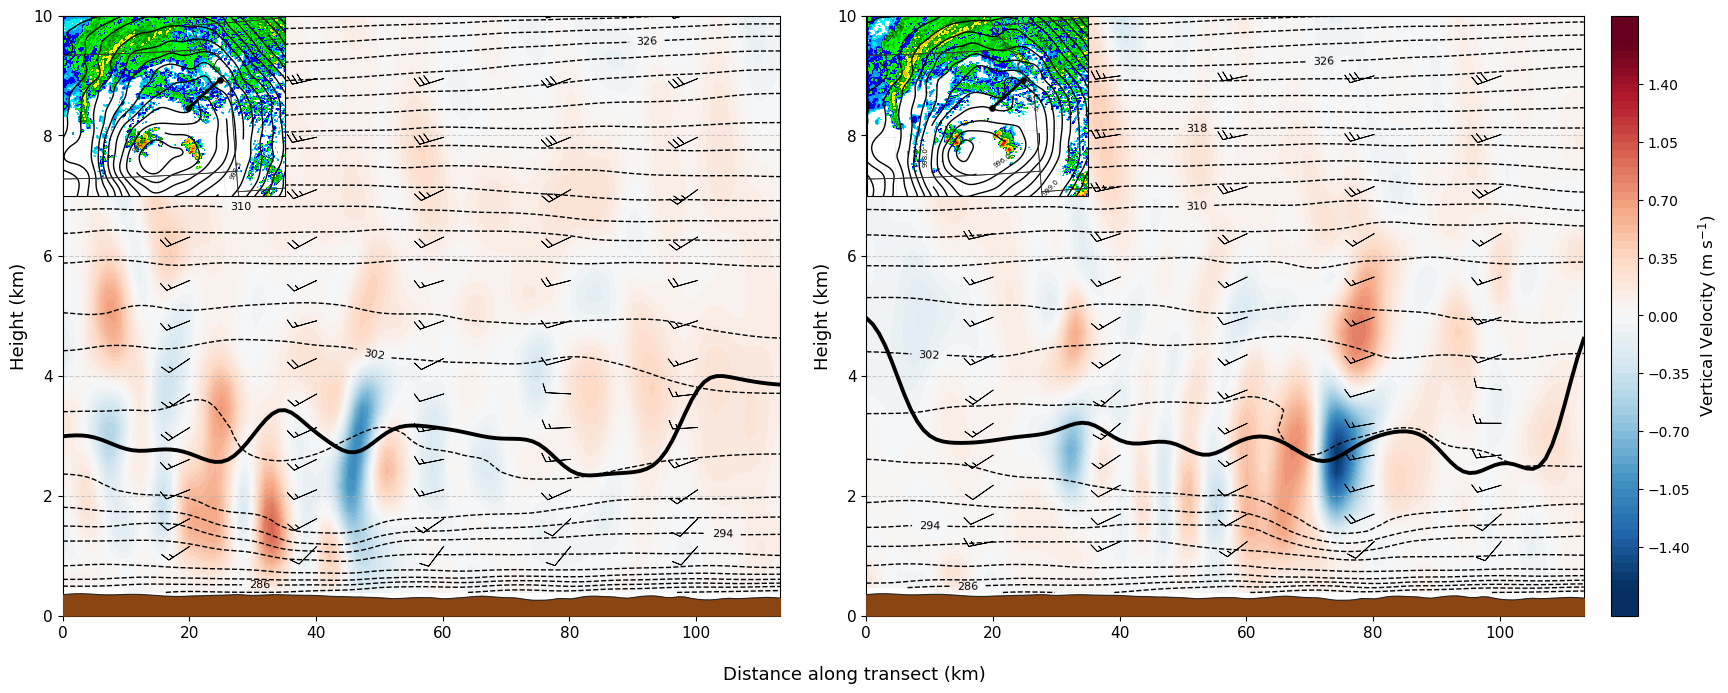

2200 UTC:
  File: /glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00
  Actual cross-section start: lat=38.604565, lon=-95.963287
  Actual cross-section end:   lat=39.238140, lon=-94.937866
  Actual transect length: 113.28 km
2230 UTC:
  File: /glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00
  Actual cross-section start: lat=38.604565, lon=-95.963287
  Actual cross-section end:   lat=39.238140, lon=-94.937866
  Actual transect length: 113.28 km
Done: publication-quality 1 x 2 subplot created.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.transforms import Bbox
from netCDF4 import Dataset
from wrf import (
    getvar, to_np, vertcross, interpline, CoordPair,
    latlon_coords, get_cartopy
)
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import warnings

import cartopy.crs as crs
from cartopy.feature import STATES, BORDERS
from metpy.plots import ctables


MIN_CL_Z_KM = 2.0
MAX_CL_Z_KM = 8.0

C = 15.0
DIR_DEG = 210.0

W_STEP = 0.05

SIG_TH = 3
SIG_W  = 1.5
SIG_UV = 0.3
SIG_Z  = 0.2

CRIT_SMOOTH_SIG = 3.0
SLP_SMOOTH_SIG = 15.0

MAP_LON_MIN = -99.8
MAP_LON_MAX = -93.2
MAP_LAT_MIN = 36.6
MAP_LAT_MAX = 40.7

BARB_LENGTH = 6.0
BARB_LW     = 0.6
BARB_SIZES  = dict(emptybarb=0.08, spacing=0.20, height=0.35)
BARB_INCS   = dict(half=5, full=10, flag=50)
MIN_BARB_Z_KM = 1.0
BARB_H_SKIP = 20

cross_start = CoordPair(lat=38.600428, lon=-95.961143)
cross_end   = CoordPair(lat=39.238070, lon=-94.943502)

FILES = [
    {
        "label": "2200 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00",
    },
    {
        "label": "2230 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00",
    },
]


def fill_small_nan_gaps(y, max_gap=3):
    y2 = y.copy()
    n = len(y2)
    isnan = ~np.isfinite(y2)
    i = 0

    while i < n:
        if not isnan[i]:
            i += 1
            continue

        start = i

        while i < n and isnan[i]:
            i += 1

        end = i
        gap_len = end - start
        left = start - 1
        right = end

        if (
            gap_len <= max_gap
            and left >= 0
            and right < n
            and np.isfinite(y2[left])
            and np.isfinite(y2[right])
        ):
            y2[start:end] = np.interp(
                np.arange(start, end),
                [left, right],
                [y2[left], y2[right]]
            )

    return y2


def smooth_valid_segments(y, sigma=3.0, min_points=5):
    y_smooth = y.copy()
    valid = np.isfinite(y_smooth)
    n = len(y_smooth)
    i = 0

    while i < n:
        if not valid[i]:
            i += 1
            continue

        start = i

        while i < n and valid[i]:
            i += 1

        end = i

        if (end - start) >= min_points:
            y_smooth[start:end] = gaussian_filter1d(
                y_smooth[start:end],
                sigma=sigma,
                mode="nearest"
            )

    return y_smooth


def process_file(filename, label):
    ncfile = Dataset(filename)

    ter   = getvar(ncfile, "ter")
    theta = getvar(ncfile, "th")
    pres  = getvar(ncfile, "pressure")
    w     = getvar(ncfile, "wa")
    z     = getvar(ncfile, "z")
    u     = getvar(ncfile, "ua")
    v     = getvar(ncfile, "va")

    mdbz = getvar(ncfile, "mdbz")
    slp  = getvar(ncfile, "slp")

    theta_cs_raw = vertcross(
        theta, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    w_cs_raw = vertcross(
        w, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    u_cs_raw = vertcross(
        u, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    v_cs_raw = vertcross(
        v, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    z_cs_raw = vertcross(
        z, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    theta_cs = gaussian_filter1d(to_np(theta_cs_raw), sigma=SIG_TH, axis=-1)
    w_cs     = gaussian_filter1d(to_np(w_cs_raw),     sigma=SIG_W,  axis=-1)
    u_cs     = gaussian_filter1d(to_np(u_cs_raw),     sigma=SIG_UV, axis=-1)
    v_cs     = gaussian_filter1d(to_np(v_cs_raw),     sigma=SIG_UV, axis=-1)
    z_cs     = gaussian_filter1d(to_np(z_cs_raw),     sigma=SIG_Z,  axis=-1)

    theta_cs = np.ma.masked_invalid(theta_cs)
    w_cs     = np.ma.masked_invalid(w_cs)
    u_cs     = np.ma.masked_invalid(u_cs)
    v_cs     = np.ma.masked_invalid(v_cs)
    z_cs     = np.ma.masked_invalid(z_cs)

    ter_line = interpline(
        ter, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end
    )

    ter_m = np.clip(to_np(ter_line), 0, None)

    coords = to_np(theta_cs_raw.coords["xy_loc"])
    lats = np.array([p.lat for p in coords], dtype=float)
    lons = np.array([p.lon for p in coords], dtype=float)

    R = 6371.0
    dist_km = np.zeros(len(lats), dtype=float)

    for i in range(1, len(lats)):
        lat1, lon1, lat2, lon2 = map(
            np.radians,
            [lats[i - 1], lons[i - 1], lats[i], lons[i]]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            np.sin(dlat / 2.0) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
        )

        dist_km[i] = dist_km[i - 1] + 2.0 * R * np.arcsin(np.sqrt(a))

    phi = np.radians(lats)
    lam = np.radians(lons)

    dlam = np.gradient(lam)
    dphi = np.gradient(phi)

    dx_t = dlam * np.cos(phi)
    dy_t = dphi

    norm_t = np.sqrt(dx_t**2 + dy_t**2)
    norm_t = np.where(norm_t == 0, np.nan, norm_t)

    dx_t = dx_t / norm_t
    dy_t = dy_t / norm_t

    t_wind = u_cs * dx_t[None, :] + v_cs * dy_t[None, :]
    n_wind = -u_cs * dy_t[None, :] + v_cs * dx_t[None, :]

    t_wind = np.ma.masked_invalid(t_wind)
    n_wind = np.ma.masked_invalid(n_wind)

    z_np_for_axis = z_cs.filled(np.nan)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        z_km = np.nanmean(z_np_for_axis, axis=1) / 1000.0

    k = np.arange(len(z_km))
    good_z = np.isfinite(z_km)

    if np.count_nonzero(good_z) < 2:
        raise ValueError("Could not construct z_km because z_cs has too many NaNs.")

    z_km = np.interp(k, k[good_z], z_km[good_z])
    z_km = np.maximum.accumulate(z_km)
    z_m = z_km * 1000.0

    sinD = np.sin(np.deg2rad(DIR_DEG))
    cosD = np.cos(np.deg2rad(DIR_DEG))

    Ucrit = (-u_cs * sinD) + (-v_cs * cosD)

    U_np = np.asarray(np.ma.filled(Ucrit, np.nan), dtype=float)
    z_np = np.asarray(np.ma.filled(z_cs, np.nan), dtype=float)

    MIN_Z_M = MIN_CL_Z_KM * 1000.0
    MAX_Z_M = MAX_CL_Z_KM * 1000.0

    crit_z = np.full(len(dist_km), np.nan)

    for ix in range(len(dist_km)):
        ucol = U_np[:, ix]
        zcol = z_np[:, ix]

        good = (
            np.isfinite(ucol)
            & np.isfinite(zcol)
            & (zcol >= MIN_Z_M)
            & (zcol <= MAX_Z_M)
        )

        if np.count_nonzero(good) < 2:
            continue

        u_good = ucol[good]
        z_good = zcol[good]

        order = np.argsort(z_good)
        z_good = z_good[order]
        u_good = u_good[order]

        diff = u_good - C
        crossings = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(crossings) == 0:
            continue

        crossing_heights = []

        for kk in crossings:
            u1 = u_good[kk]
            u2 = u_good[kk + 1]
            z1 = z_good[kk]
            z2 = z_good[kk + 1]

            if not np.isfinite(u1) or not np.isfinite(u2):
                continue

            if u2 != u1:
                zc = z1 + (C - u1) * (z2 - z1) / (u2 - u1)
            else:
                zc = z1

            if MIN_Z_M <= zc <= MAX_Z_M:
                crossing_heights.append(zc)

        if len(crossing_heights) > 0:
            crit_z[ix] = np.min(crossing_heights)

    crit_z[crit_z <= ter_m] = np.nan

    crit_z_plot = fill_small_nan_gaps(crit_z, max_gap=3)
    crit_z_plot[crit_z_plot <= ter_m] = np.nan

    crit_z_plot = smooth_valid_segments(
        crit_z_plot,
        sigma=CRIT_SMOOTH_SIG,
        min_points=5
    )

    crit_z_plot[crit_z_plot <= ter_m] = np.nan

    dist_km_plot = dist_km
    theta_cs_plot = theta_cs
    w_cs_plot     = w_cs
    t_wind_plot   = t_wind
    n_wind_plot   = n_wind
    ter_m_plot    = ter_m

    theta_levels = np.arange(
        np.floor(np.nanmin(theta_cs_plot) / 2.0) * 2.0,
        np.ceil(np.nanmax(theta_cs_plot) / 2.0) * 2.0 + 2.0,
        2.0
    )

    lats2d, lons2d = latlon_coords(mdbz)
    cart_proj = get_cartopy(mdbz)

    out = {
        "label": label,
        "filename": filename,
        "dist_km_plot": dist_km_plot,
        "z_km": z_km,
        "z_m": z_m,
        "theta_cs_plot": theta_cs_plot,
        "w_cs_plot": w_cs_plot,
        "t_wind_plot": t_wind_plot,
        "n_wind_plot": n_wind_plot,
        "ter_m_plot": ter_m_plot,
        "crit_z_plot": crit_z_plot,
        "theta_levels": theta_levels,
        "mdbz_np": to_np(mdbz),
        "slp_np": to_np(slp),
        "lats2d": to_np(lats2d),
        "lons2d": to_np(lons2d),
        "cart_proj": cart_proj,
        "start_lat": float(lats[0]),
        "start_lon": float(lons[0]),
        "end_lat": float(lats[-1]),
        "end_lon": float(lons[-1]),
        "transect_length": dist_km[-1],
    }

    ncfile.close()

    return out


results = []

for item in FILES:
    results.append(process_file(item["filename"], item["label"]))

all_w = []

for result in results:
    w_np = result["w_cs_plot"].filled(np.nan)
    finite_w = np.isfinite(w_np)

    if not np.any(finite_w):
        raise ValueError(f"No finite vertical velocity values found for {result['label']}.")

    all_w.append(w_np[finite_w])

all_w = np.concatenate(all_w)

wmin = float(np.nanmin(all_w))
wmax = float(np.nanmax(all_w))

absmax = max(abs(wmin), abs(wmax))
wmin = -absmax
wmax = absmax

wmin_r = np.floor(wmin / W_STEP) * W_STEP
wmax_r = np.ceil(wmax / W_STEP) * W_STEP

levels_w = np.arange(wmin_r, wmax_r + 0.5 * W_STEP, W_STEP)
norm_w = TwoSlopeNorm(vmin=wmin_r, vcenter=0.0, vmax=wmax_r)

print(
    f"Shared w color scale: min={wmin_r:.3f} m/s, max={wmax_r:.3f} m/s "
    f"using combined plotted-time values."
)

nws_ref = ctables.registry.get_with_steps("NWSReflectivity", 5, 5)

if isinstance(nws_ref[0], BoundaryNorm):
    ref_norm = nws_ref[0]
    ref_cmap = nws_ref[1]
else:
    ref_cmap = nws_ref[0]
    ref_norm = nws_ref[1]

dbz_levels = np.arange(5, 80, 5)

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7.5),
    sharey=True
)

cf_for_cbar = None

for i, (ax, result) in enumerate(zip(axes, results)):
    cf = ax.contourf(
        result["dist_km_plot"],
        result["z_m"],
        result["w_cs_plot"],
        levels=levels_w,
        cmap="RdBu_r",
        norm=norm_w,
        extend="both"
    )

    cf_for_cbar = cf

    cs = ax.contour(
        result["dist_km_plot"],
        result["z_m"],
        result["theta_cs_plot"],
        levels=result["theta_levels"],
        colors="k",
        linestyles="dashed",
        linewidths=1.0
    )

    ax.clabel(cs, result["theta_levels"][::4], fontsize=8)

    horz = slice(0, None, BARB_H_SKIP)

    vidx = (
        list(range(2, min(14, len(result["z_km"])), 6))
        + list(range(min(14, len(result["z_km"])), len(result["z_km"]), 5))
    )

    vidx = [
        kk for kk in vidx
        if np.isfinite(result["z_km"][kk])
        and result["z_km"][kk] >= MIN_BARB_Z_KM
    ]

    if len(vidx) > 0:
        ax.barbs(
            result["dist_km_plot"][horz],
            result["z_m"][vidx],
            result["t_wind_plot"][vidx][:, horz],
            result["n_wind_plot"][vidx][:, horz],
            color="k",
            length=BARB_LENGTH,
            linewidth=BARB_LW,
            sizes=BARB_SIZES,
            barb_increments=BARB_INCS,
            zorder=7
        )

    if np.count_nonzero(np.isfinite(result["crit_z_plot"])) >= 2:
        ax.plot(
            result["dist_km_plot"],
            result["crit_z_plot"],
            color="black",
            linewidth=2.8,
            zorder=12
        )

    elif np.count_nonzero(np.isfinite(result["crit_z_plot"])) == 1:
        ax.scatter(
            result["dist_km_plot"][np.isfinite(result["crit_z_plot"])],
            result["crit_z_plot"][np.isfinite(result["crit_z_plot"])],
            color="black",
            s=35,
            zorder=13
        )

    ax.fill_between(
        result["dist_km_plot"],
        0,
        result["ter_m_plot"],
        color="saddlebrown",
        zorder=5
    )

    ax.plot(
        result["dist_km_plot"],
        result["ter_m_plot"],
        color="0.15",
        linewidth=0.8,
        zorder=6
    )

    ax.set_ylim(0, 10000)
    ax.set_yticks(np.arange(0, 10001, 2000))
    ax.set_yticklabels((np.arange(0, 10001, 2000) / 1000).astype(int))

    ax.set_xlabel("")
    ax.set_ylabel("Height (km)", fontsize=13)

    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.tick_params(axis="y", labelleft=True)

    ax.grid(axis="y", linestyle="--", alpha=0.6)

fig.supxlabel("Distance along transect (km)", fontsize=13, y=0.045)

fig.subplots_adjust(
    left=0.060,
    right=0.905,
    bottom=0.135,
    top=0.935,
    wspace=0.12
)

bbox = Bbox.union([ax.get_position() for ax in axes])

cax = fig.add_axes([
    bbox.x1 + 0.015,
    bbox.y0,
    0.015,
    bbox.height
])

cbar = fig.colorbar(cf_for_cbar, cax=cax, extendrect=True)
cbar.set_label("Vertical Velocity (m s$^{-1}$)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

for ax, result in zip(axes, results):
    bbox = ax.get_position()

    inset_width = 0.36 * bbox.width
    inset_height = 0.30 * bbox.height
    inset_left = bbox.x0 - 0.025 * bbox.width
    inset_bottom = bbox.y1 - inset_height + 0.000 * bbox.height

    ax_inset = fig.add_axes(
        [inset_left, inset_bottom, inset_width, inset_height],
        projection=result["cart_proj"]
    )

    mdbz_plot = np.ma.masked_less(result["mdbz_np"], 5.0)

    ax_inset.contourf(
        result["lons2d"],
        result["lats2d"],
        mdbz_plot,
        levels=dbz_levels,
        cmap=ref_cmap,
        norm=ref_norm,
        transform=crs.PlateCarree(),
        extend="max",
        zorder=1
    )

    slp_smooth = gaussian_filter(result["slp_np"], sigma=SLP_SMOOTH_SIG)

    slp_min = np.floor(np.nanmin(slp_smooth) * 2.0) / 2.0
    slp_max = np.ceil(np.nanmax(slp_smooth) * 2.0) / 2.0
    slp_levels = np.arange(slp_min, slp_max + 0.5, 0.5)

    slp_cs = ax_inset.contour(
        result["lons2d"],
        result["lats2d"],
        slp_smooth,
        levels=slp_levels,
        colors="black",
        linewidths=1,
        transform=crs.PlateCarree(),
        zorder=4
    )

    ax_inset.clabel(
        slp_cs,
        slp_levels[::2],
        inline=True,
        fontsize=5,
        fmt="%.1f"
    )

    ax_inset.plot(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        color="black",
        linewidth=2.0,
        transform=crs.PlateCarree(),
        zorder=8
    )

    ax_inset.scatter(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        s=20,
        color="black",
        edgecolor="black",
        linewidth=0.3,
        transform=crs.PlateCarree(),
        zorder=9
    )

    ax_inset.add_feature(
        STATES.with_scale("50m"),
        linewidth=0.55,
        edgecolor="0.20",
        zorder=6
    )

    ax_inset.add_feature(
        BORDERS.with_scale("50m"),
        linewidth=0.35,
        edgecolor="0.35",
        zorder=6
    )

    ax_inset.set_extent(
        [MAP_LON_MIN, MAP_LON_MAX, MAP_LAT_MIN, MAP_LAT_MAX],
        crs=crs.PlateCarree()
    )

    ax_inset.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

plt.savefig(
     "Wave-Cisk_VCS.png",
     dpi=600,
     bbox_inches="tight"
)

plt.show()

for result in results:
    print(f"{result['label']}:")
    print(f"  File: {result['filename']}")
    print(f"  Actual cross-section start: lat={result['start_lat']:.6f}, lon={result['start_lon']:.6f}")
    print(f"  Actual cross-section end:   lat={result['end_lat']:.6f}, lon={result['end_lon']:.6f}")
    print(f"  Actual transect length: {result['transect_length']:.2f} km")

print("Done: publication-quality 1 x 2 subplot created.")

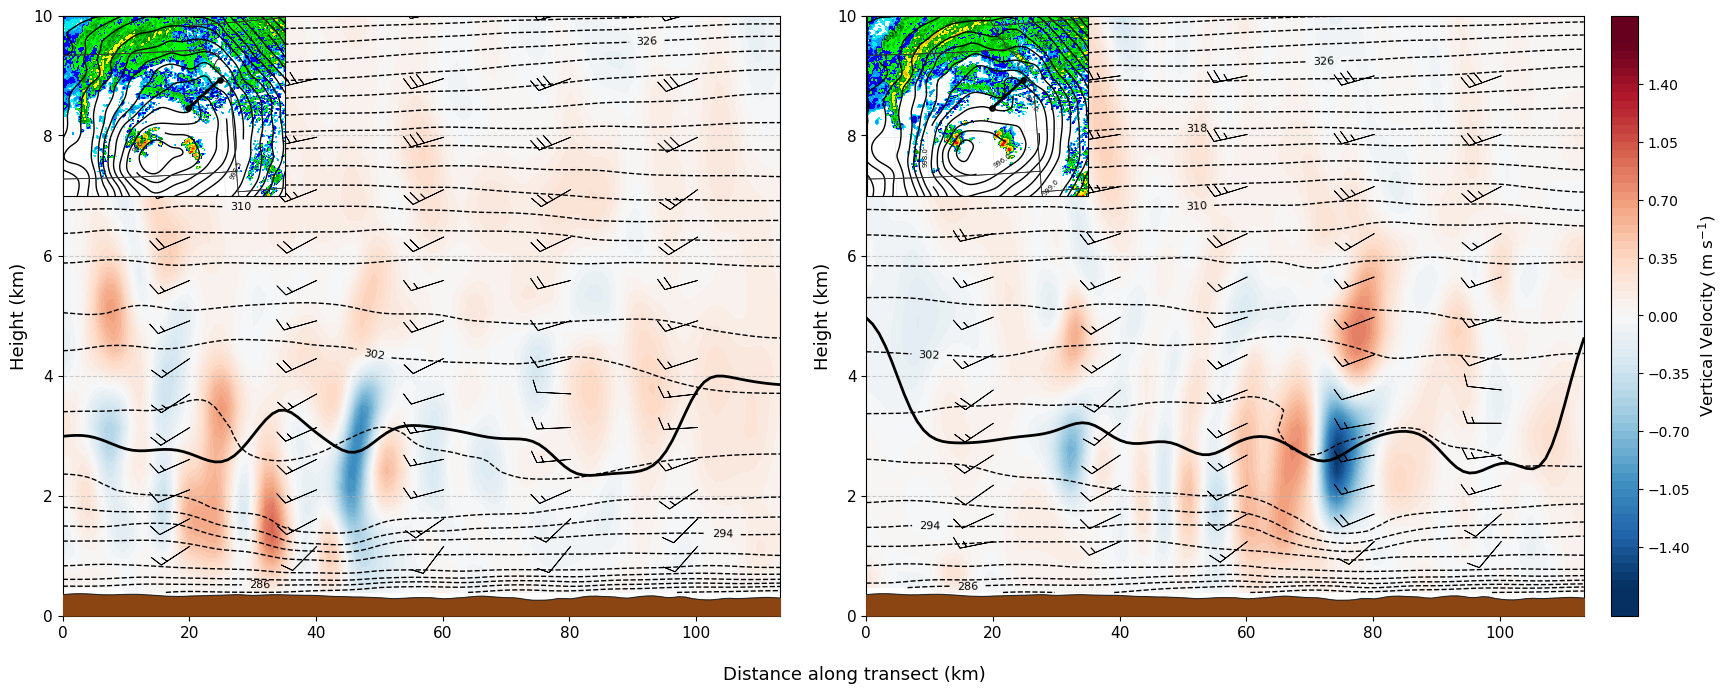

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.transforms import Bbox
from netCDF4 import Dataset
from wrf import (
    getvar, to_np, vertcross, interpline, CoordPair,
    latlon_coords, get_cartopy
)
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import warnings

import cartopy.crs as crs
from cartopy.feature import STATES, BORDERS
from metpy.plots import ctables


# basic settings
MIN_CL_Z_KM = 2.0
MAX_CL_Z_KM = 8.0

C = 15.0
DIR_DEG = 210.0

W_STEP = 0.05

SIG_TH = 3
SIG_W  = 1.5
SIG_UV = 0.3
SIG_Z  = 0.2

CRIT_SMOOTH_SIG = 3.0
SLP_SMOOTH_SIG = 15.0

MAP_LON_MIN = -99.8
MAP_LON_MAX = -93.2
MAP_LAT_MIN = 36.6
MAP_LAT_MAX = 40.7

# wind barb settings
BARB_LENGTH = 7.0
BARB_LW     = 0.6
BARB_SIZES  = dict(emptybarb=0.08, spacing=0.20, height=0.35)
BARB_INCS   = dict(half=5, full=10, flag=50)
MIN_BARB_Z_KM = 1.0
BARB_H_SKIP = 20

# cross-section endpoints
cross_start = CoordPair(lat=38.600428, lon=-95.961143)
cross_end   = CoordPair(lat=39.238070, lon=-94.943502)

# WRF files
FILES = [
    {
        "label": "2200 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00",
    },
    {
        "label": "2230 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00",
    },
]


def fill_small_nan_gaps(y, max_gap=3):
    y2 = y.copy()
    n = len(y2)
    isnan = ~np.isfinite(y2)
    i = 0

    while i < n:
        if not isnan[i]:
            i += 1
            continue

        start = i

        while i < n and isnan[i]:
            i += 1

        end = i
        gap_len = end - start
        left = start - 1
        right = end

        if (
            gap_len <= max_gap
            and left >= 0
            and right < n
            and np.isfinite(y2[left])
            and np.isfinite(y2[right])
        ):
            y2[start:end] = np.interp(
                np.arange(start, end),
                [left, right],
                [y2[left], y2[right]]
            )

    return y2


def smooth_valid_segments(y, sigma=3.0, min_points=5):
    y_smooth = y.copy()
    valid = np.isfinite(y_smooth)
    n = len(y_smooth)
    i = 0

    while i < n:
        if not valid[i]:
            i += 1
            continue

        start = i

        while i < n and valid[i]:
            i += 1

        end = i

        if (end - start) >= min_points:
            y_smooth[start:end] = gaussian_filter1d(
                y_smooth[start:end],
                sigma=sigma,
                mode="nearest"
            )

    return y_smooth


def get_distance_km(lats, lons):
    R = 6371.0
    dist_km = np.zeros(len(lats), dtype=float)

    for i in range(1, len(lats)):
        lat1, lon1, lat2, lon2 = map(
            np.radians,
            [lats[i - 1], lons[i - 1], lats[i], lons[i]]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            np.sin(dlat / 2.0) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
        )

        dist_km[i] = dist_km[i - 1] + 2.0 * R * np.arcsin(np.sqrt(a))

    return dist_km


def get_transect_wind_components(u_cs, v_cs, lats, lons):
    phi = np.radians(lats)
    lam = np.radians(lons)

    dlam = np.gradient(lam)
    dphi = np.gradient(phi)

    dx_t = dlam * np.cos(phi)
    dy_t = dphi

    norm_t = np.sqrt(dx_t**2 + dy_t**2)
    norm_t = np.where(norm_t == 0, np.nan, norm_t)

    dx_t = dx_t / norm_t
    dy_t = dy_t / norm_t

    t_wind = u_cs * dx_t[None, :] + v_cs * dy_t[None, :]
    n_wind = -u_cs * dy_t[None, :] + v_cs * dx_t[None, :]

    t_wind = np.ma.masked_invalid(t_wind)
    n_wind = np.ma.masked_invalid(n_wind)

    return t_wind, n_wind


def get_height_axis(z_cs):
    z_np = z_cs.filled(np.nan)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        z_km = np.nanmean(z_np, axis=1) / 1000.0

    k = np.arange(len(z_km))
    good_z = np.isfinite(z_km)

    if np.count_nonzero(good_z) < 2:
        raise ValueError("Could not construct the height axis.")

    z_km = np.interp(k, k[good_z], z_km[good_z])
    z_km = np.maximum.accumulate(z_km)

    return z_km, z_km * 1000.0


def get_critical_level(u_cs, v_cs, z_cs, ter_m):
    sinD = np.sin(np.deg2rad(DIR_DEG))
    cosD = np.cos(np.deg2rad(DIR_DEG))

    Ucrit = (-u_cs * sinD) + (-v_cs * cosD)

    U_np = np.asarray(np.ma.filled(Ucrit, np.nan), dtype=float)
    z_np = np.asarray(np.ma.filled(z_cs, np.nan), dtype=float)

    min_z_m = MIN_CL_Z_KM * 1000.0
    max_z_m = MAX_CL_Z_KM * 1000.0

    crit_z = np.full(U_np.shape[1], np.nan)

    for ix in range(U_np.shape[1]):
        ucol = U_np[:, ix]
        zcol = z_np[:, ix]

        good = (
            np.isfinite(ucol)
            & np.isfinite(zcol)
            & (zcol >= min_z_m)
            & (zcol <= max_z_m)
        )

        if np.count_nonzero(good) < 2:
            continue

        u_good = ucol[good]
        z_good = zcol[good]

        order = np.argsort(z_good)
        z_good = z_good[order]
        u_good = u_good[order]

        diff = u_good - C
        crossings = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(crossings) == 0:
            continue

        crossing_heights = []

        for kk in crossings:
            u1 = u_good[kk]
            u2 = u_good[kk + 1]
            z1 = z_good[kk]
            z2 = z_good[kk + 1]

            if u2 != u1:
                zc = z1 + (C - u1) * (z2 - z1) / (u2 - u1)
            else:
                zc = z1

            if min_z_m <= zc <= max_z_m:
                crossing_heights.append(zc)

        if len(crossing_heights) > 0:
            crit_z[ix] = np.min(crossing_heights)

    crit_z[crit_z <= ter_m] = np.nan

    crit_z = fill_small_nan_gaps(crit_z, max_gap=3)
    crit_z[crit_z <= ter_m] = np.nan

    crit_z = smooth_valid_segments(
        crit_z,
        sigma=CRIT_SMOOTH_SIG,
        min_points=5
    )

    crit_z[crit_z <= ter_m] = np.nan

    return crit_z


def process_file(filename, label):
    ncfile = Dataset(filename)

    # read WRF variables
    ter   = getvar(ncfile, "ter")
    theta = getvar(ncfile, "th")
    pres  = getvar(ncfile, "pressure")
    w     = getvar(ncfile, "wa")
    z     = getvar(ncfile, "z")
    u     = getvar(ncfile, "ua")
    v     = getvar(ncfile, "va")

    mdbz = getvar(ncfile, "mdbz")
    slp  = getvar(ncfile, "slp")

    # make cross sections
    theta_cs_raw = vertcross(
        theta, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    w_cs_raw = vertcross(
        w, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    u_cs_raw = vertcross(
        u, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    v_cs_raw = vertcross(
        v, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    z_cs_raw = vertcross(
        z, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    # smooth fields along the transect
    theta_cs = gaussian_filter1d(to_np(theta_cs_raw), sigma=SIG_TH, axis=-1)
    w_cs     = gaussian_filter1d(to_np(w_cs_raw),     sigma=SIG_W,  axis=-1)
    u_cs     = gaussian_filter1d(to_np(u_cs_raw),     sigma=SIG_UV, axis=-1)
    v_cs     = gaussian_filter1d(to_np(v_cs_raw),     sigma=SIG_UV, axis=-1)
    z_cs     = gaussian_filter1d(to_np(z_cs_raw),     sigma=SIG_Z,  axis=-1)

    theta_cs = np.ma.masked_invalid(theta_cs)
    w_cs     = np.ma.masked_invalid(w_cs)
    u_cs     = np.ma.masked_invalid(u_cs)
    v_cs     = np.ma.masked_invalid(v_cs)
    z_cs     = np.ma.masked_invalid(z_cs)

    # terrain along the transect
    ter_line = interpline(
        ter, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end
    )

    ter_m = np.clip(to_np(ter_line), 0, None)

    # distance along the transect
    coords = to_np(theta_cs_raw.coords["xy_loc"])
    lats = np.array([p.lat for p in coords], dtype=float)
    lons = np.array([p.lon for p in coords], dtype=float)
    dist_km = get_distance_km(lats, lons)

    # transect-relative wind components
    t_wind, n_wind = get_transect_wind_components(u_cs, v_cs, lats, lons)

    # height axis
    z_km, z_m = get_height_axis(z_cs)

    # critical level
    crit_z = get_critical_level(u_cs, v_cs, z_cs, ter_m)

    # theta contour levels
    theta_levels = np.arange(
        np.floor(np.nanmin(theta_cs) / 2.0) * 2.0,
        np.ceil(np.nanmax(theta_cs) / 2.0) * 2.0 + 2.0,
        2.0
    )

    # map fields
    lats2d, lons2d = latlon_coords(mdbz)
    cart_proj = get_cartopy(mdbz)

    ncfile.close()

    return {
        "label": label,
        "filename": filename,
        "dist_km": dist_km,
        "z_km": z_km,
        "z_m": z_m,
        "theta_cs": theta_cs,
        "w_cs": w_cs,
        "t_wind": t_wind,
        "n_wind": n_wind,
        "ter_m": ter_m,
        "crit_z": crit_z,
        "theta_levels": theta_levels,
        "mdbz": to_np(mdbz),
        "slp": to_np(slp),
        "lats2d": to_np(lats2d),
        "lons2d": to_np(lons2d),
        "cart_proj": cart_proj,
        "start_lat": float(lats[0]),
        "start_lon": float(lons[0]),
        "end_lat": float(lats[-1]),
        "end_lon": float(lons[-1]),
    }


# process both times
results = [process_file(item["filename"], item["label"]) for item in FILES]

# shared vertical velocity color scale
all_w = []

for result in results:
    w_np = result["w_cs"].filled(np.nan)
    all_w.append(w_np[np.isfinite(w_np)])

all_w = np.concatenate(all_w)

wmin = float(np.nanmin(all_w))
wmax = float(np.nanmax(all_w))

absmax = max(abs(wmin), abs(wmax))
wmin = -absmax
wmax = absmax

wmin_r = np.floor(wmin / W_STEP) * W_STEP
wmax_r = np.ceil(wmax / W_STEP) * W_STEP

levels_w = np.arange(wmin_r, wmax_r + 0.5 * W_STEP, W_STEP)
norm_w = TwoSlopeNorm(vmin=wmin_r, vcenter=0.0, vmax=wmax_r)

# reflectivity color table
nws_ref = ctables.registry.get_with_steps("NWSReflectivity", 5, 5)

if isinstance(nws_ref[0], BoundaryNorm):
    ref_norm = nws_ref[0]
    ref_cmap = nws_ref[1]
else:
    ref_cmap = nws_ref[0]
    ref_norm = nws_ref[1]

dbz_levels = np.arange(5, 80, 5)

# make figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7.5),
    sharey=True
)

cf_for_cbar = None

for ax, result in zip(axes, results):

    # vertical velocity
    cf = ax.contourf(
        result["dist_km"],
        result["z_m"],
        result["w_cs"],
        levels=levels_w,
        cmap="RdBu_r",
        norm=norm_w,
        extend="both"
    )

    cf_for_cbar = cf

    # potential temperature
    cs = ax.contour(
        result["dist_km"],
        result["z_m"],
        result["theta_cs"],
        levels=result["theta_levels"],
        colors="k",
        linestyles="dashed",
        linewidths=1.0
    )

    ax.clabel(cs, result["theta_levels"][::4], fontsize=8)

    # wind barbs
    horz = slice(0, None, BARB_H_SKIP)

    vidx = (
        list(range(2, min(14, len(result["z_km"])), 6))
        + list(range(min(14, len(result["z_km"])), len(result["z_km"]), 5))
    )

    vidx = [
        kk for kk in vidx
        if np.isfinite(result["z_km"][kk])
        and result["z_km"][kk] >= MIN_BARB_Z_KM
    ]

    if len(vidx) > 0:
        ax.barbs(
            result["dist_km"][horz],
            result["z_m"][vidx],
            result["t_wind"][vidx][:, horz],
            result["n_wind"][vidx][:, horz],
            color="k",
            length=BARB_LENGTH,
            linewidth=BARB_LW,
            sizes=BARB_SIZES,
            barb_increments=BARB_INCS,
            zorder=7
        )

    # critical level
    if np.count_nonzero(np.isfinite(result["crit_z"])) >= 2:
        ax.plot(
            result["dist_km"],
            result["crit_z"],
            color="black",
            linewidth=2,
            zorder=12
        )

    elif np.count_nonzero(np.isfinite(result["crit_z"])) == 1:
        ax.scatter(
            result["dist_km"][np.isfinite(result["crit_z"])],
            result["crit_z"][np.isfinite(result["crit_z"])],
            color="black",
            s=35,
            zorder=13
        )

    # terrain
    ax.fill_between(
        result["dist_km"],
        0,
        result["ter_m"],
        color="saddlebrown",
        zorder=5
    )

    ax.plot(
        result["dist_km"],
        result["ter_m"],
        color="0.15",
        linewidth=0.8,
        zorder=6
    )

    ax.set_ylim(0, 10000)
    ax.set_yticks(np.arange(0, 10001, 2000))
    ax.set_yticklabels((np.arange(0, 10001, 2000) / 1000).astype(int))

    ax.set_xlabel("")
    ax.set_ylabel("Height (km)", fontsize=13)

    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.tick_params(axis="y", labelleft=True)

    ax.grid(axis="y", linestyle="--", alpha=0.6)

fig.supxlabel("Distance along transect (km)", fontsize=13, y=0.045)

fig.subplots_adjust(
    left=0.060,
    right=0.905,
    bottom=0.135,
    top=0.935,
    wspace=0.12
)

# colorbar
bbox = Bbox.union([ax.get_position() for ax in axes])

cax = fig.add_axes([
    bbox.x1 + 0.015,
    bbox.y0,
    0.015,
    bbox.height
])

cbar = fig.colorbar(cf_for_cbar, cax=cax, extendrect=True)
cbar.set_label("Vertical Velocity (m s$^{-1}$)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# inset maps
for ax, result in zip(axes, results):
    bbox = ax.get_position()

    inset_width = 0.36 * bbox.width
    inset_height = 0.30 * bbox.height
    inset_left = bbox.x0 - 0.025 * bbox.width
    inset_bottom = bbox.y1 - inset_height

    ax_inset = fig.add_axes(
        [inset_left, inset_bottom, inset_width, inset_height],
        projection=result["cart_proj"]
    )

    # reflectivity
    mdbz_plot = np.ma.masked_less(result["mdbz"], 5.0)

    ax_inset.contourf(
        result["lons2d"],
        result["lats2d"],
        mdbz_plot,
        levels=dbz_levels,
        cmap=ref_cmap,
        norm=ref_norm,
        transform=crs.PlateCarree(),
        extend="max",
        zorder=1
    )

    # sea-level pressure
    slp_smooth = gaussian_filter(result["slp"], sigma=SLP_SMOOTH_SIG)

    slp_min = np.floor(np.nanmin(slp_smooth) * 2.0) / 2.0
    slp_max = np.ceil(np.nanmax(slp_smooth) * 2.0) / 2.0
    slp_levels = np.arange(slp_min, slp_max + 0.5, 0.5)

    slp_cs = ax_inset.contour(
        result["lons2d"],
        result["lats2d"],
        slp_smooth,
        levels=slp_levels,
        colors="black",
        linewidths=1,
        transform=crs.PlateCarree(),
        zorder=4
    )

    ax_inset.clabel(
        slp_cs,
        slp_levels[::2],
        inline=True,
        fontsize=5,
        fmt="%.1f"
    )

    # transect line
    ax_inset.plot(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        color="black",
        linewidth=2.0,
        transform=crs.PlateCarree(),
        zorder=8
    )

    ax_inset.scatter(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        s=20,
        color="black",
        edgecolor="black",
        linewidth=0.3,
        transform=crs.PlateCarree(),
        zorder=9
    )

    # map features
    ax_inset.add_feature(
        STATES.with_scale("50m"),
        linewidth=0.55,
        edgecolor="0.20",
        zorder=6
    )

    ax_inset.add_feature(
        BORDERS.with_scale("50m"),
        linewidth=0.35,
        edgecolor="0.35",
        zorder=6
    )

    ax_inset.set_extent(
        [MAP_LON_MIN, MAP_LON_MAX, MAP_LAT_MIN, MAP_LAT_MAX],
        crs=crs.PlateCarree()
    )

    ax_inset.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

plt.savefig(
    "Wave-Cisk_VCS.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

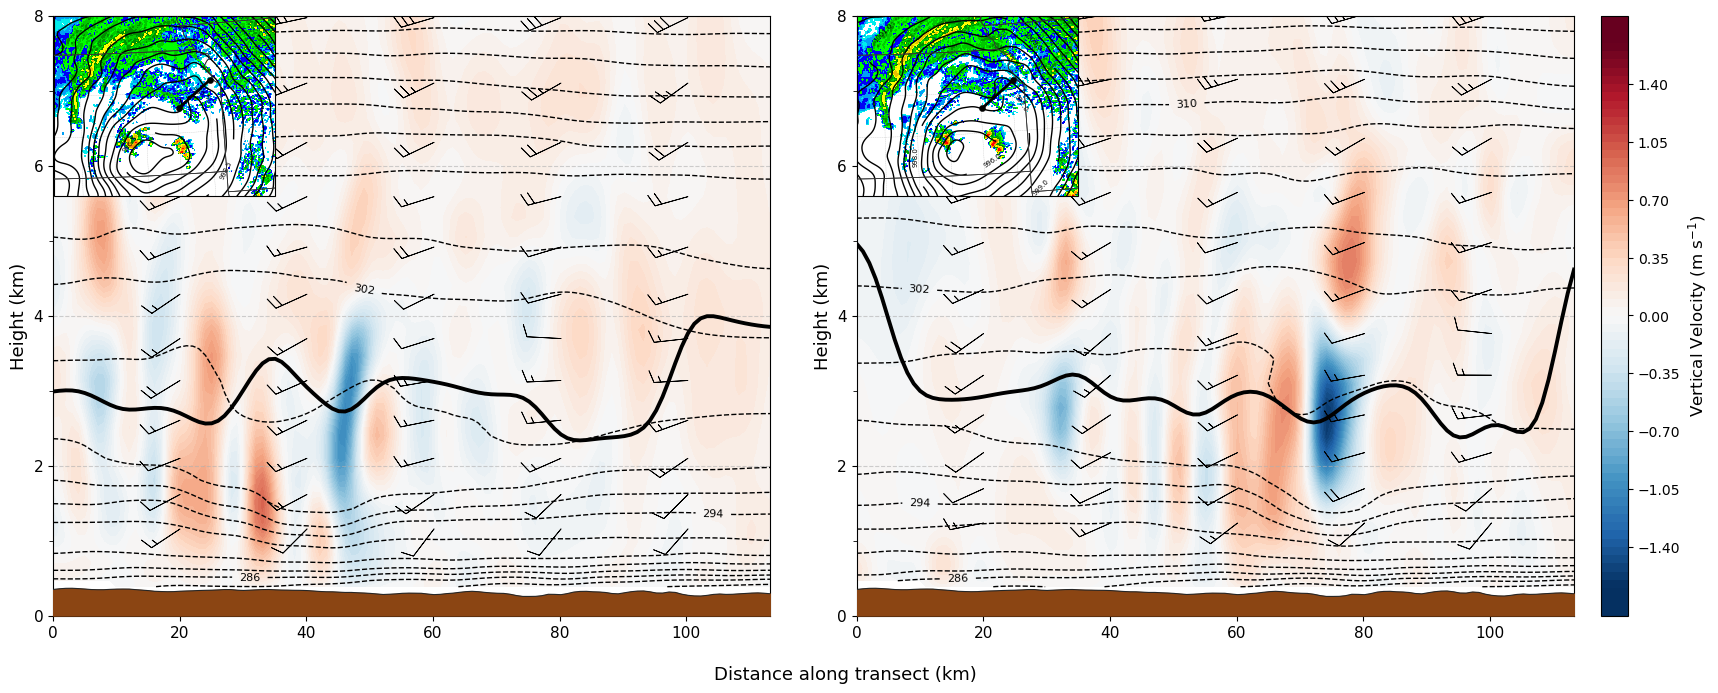

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.transforms import Bbox
from netCDF4 import Dataset
from wrf import (
    getvar, to_np, vertcross, interpline, CoordPair,
    latlon_coords, get_cartopy
)
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import warnings

import cartopy.crs as crs
from cartopy.feature import STATES, BORDERS
from metpy.plots import ctables


# basic settings
MIN_CL_Z_KM = 2.0
MAX_CL_Z_KM = 8.0

C = 15.0
DIR_DEG = 210.0

W_STEP = 0.05

SIG_TH = 3
SIG_W  = 1.5
SIG_UV = 0.3
SIG_Z  = 0.2

CRIT_SMOOTH_SIG = 3.0
SLP_SMOOTH_SIG = 15.0

MAP_LON_MIN = -99.8
MAP_LON_MAX = -93.2
MAP_LAT_MIN = 36.6
MAP_LAT_MAX = 40.7

# wind barb settings
BARB_LENGTH = 7.0
BARB_LW     = 0.6
BARB_SIZES  = dict(emptybarb=0.08, spacing=0.20, height=0.35)
BARB_INCS   = dict(half=5, full=10, flag=50)
MIN_BARB_Z_KM = 1.0
BARB_H_SKIP = 20

# cross-section endpoints
cross_start = CoordPair(lat=38.600428, lon=-95.961143)
cross_end   = CoordPair(lat=39.238070, lon=-94.943502)

# WRF files
FILES = [
    {
        "label": "2200 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:00:00",
    },
    {
        "label": "2230 UTC",
        "filename": "/glade/work/rbhandari/data/SIM_Feb14_MP2/wrfout_d03_1992-02-14_22:30:00",
    },
]


def fill_small_nan_gaps(y, max_gap=3):
    y2 = y.copy()
    n = len(y2)
    isnan = ~np.isfinite(y2)
    i = 0

    while i < n:
        if not isnan[i]:
            i += 1
            continue

        start = i

        while i < n and isnan[i]:
            i += 1

        end = i
        gap_len = end - start
        left = start - 1
        right = end

        if (
            gap_len <= max_gap
            and left >= 0
            and right < n
            and np.isfinite(y2[left])
            and np.isfinite(y2[right])
        ):
            y2[start:end] = np.interp(
                np.arange(start, end),
                [left, right],
                [y2[left], y2[right]]
            )

    return y2


def smooth_valid_segments(y, sigma=3.0, min_points=5):
    y_smooth = y.copy()
    valid = np.isfinite(y_smooth)
    n = len(y_smooth)
    i = 0

    while i < n:
        if not valid[i]:
            i += 1
            continue

        start = i

        while i < n and valid[i]:
            i += 1

        end = i

        if (end - start) >= min_points:
            y_smooth[start:end] = gaussian_filter1d(
                y_smooth[start:end],
                sigma=sigma,
                mode="nearest"
            )

    return y_smooth


def get_distance_km(lats, lons):
    R = 6371.0
    dist_km = np.zeros(len(lats), dtype=float)

    for i in range(1, len(lats)):
        lat1, lon1, lat2, lon2 = map(
            np.radians,
            [lats[i - 1], lons[i - 1], lats[i], lons[i]]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            np.sin(dlat / 2.0) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
        )

        dist_km[i] = dist_km[i - 1] + 2.0 * R * np.arcsin(np.sqrt(a))

    return dist_km


def get_transect_wind_components(u_cs, v_cs, lats, lons):
    phi = np.radians(lats)
    lam = np.radians(lons)

    dlam = np.gradient(lam)
    dphi = np.gradient(phi)

    dx_t = dlam * np.cos(phi)
    dy_t = dphi

    norm_t = np.sqrt(dx_t**2 + dy_t**2)
    norm_t = np.where(norm_t == 0, np.nan, norm_t)

    dx_t = dx_t / norm_t
    dy_t = dy_t / norm_t

    t_wind = u_cs * dx_t[None, :] + v_cs * dy_t[None, :]
    n_wind = -u_cs * dy_t[None, :] + v_cs * dx_t[None, :]

    t_wind = np.ma.masked_invalid(t_wind)
    n_wind = np.ma.masked_invalid(n_wind)

    return t_wind, n_wind


def get_height_axis(z_cs):
    z_np = z_cs.filled(np.nan)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        z_km = np.nanmean(z_np, axis=1) / 1000.0

    k = np.arange(len(z_km))
    good_z = np.isfinite(z_km)

    if np.count_nonzero(good_z) < 2:
        raise ValueError("Could not construct the height axis.")

    z_km = np.interp(k, k[good_z], z_km[good_z])
    z_km = np.maximum.accumulate(z_km)

    return z_km, z_km * 1000.0


def get_critical_level(u_cs, v_cs, z_cs, ter_m):
    sinD = np.sin(np.deg2rad(DIR_DEG))
    cosD = np.cos(np.deg2rad(DIR_DEG))

    Ucrit = (-u_cs * sinD) + (-v_cs * cosD)

    U_np = np.asarray(np.ma.filled(Ucrit, np.nan), dtype=float)
    z_np = np.asarray(np.ma.filled(z_cs, np.nan), dtype=float)

    min_z_m = MIN_CL_Z_KM * 1000.0
    max_z_m = MAX_CL_Z_KM * 1000.0

    crit_z = np.full(U_np.shape[1], np.nan)

    for ix in range(U_np.shape[1]):
        ucol = U_np[:, ix]
        zcol = z_np[:, ix]

        good = (
            np.isfinite(ucol)
            & np.isfinite(zcol)
            & (zcol >= min_z_m)
            & (zcol <= max_z_m)
        )

        if np.count_nonzero(good) < 2:
            continue

        u_good = ucol[good]
        z_good = zcol[good]

        order = np.argsort(z_good)
        z_good = z_good[order]
        u_good = u_good[order]

        diff = u_good - C
        crossings = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(crossings) == 0:
            continue

        crossing_heights = []

        for kk in crossings:
            u1 = u_good[kk]
            u2 = u_good[kk + 1]
            z1 = z_good[kk]
            z2 = z_good[kk + 1]

            if u2 != u1:
                zc = z1 + (C - u1) * (z2 - z1) / (u2 - u1)
            else:
                zc = z1

            if min_z_m <= zc <= max_z_m:
                crossing_heights.append(zc)

        if len(crossing_heights) > 0:
            crit_z[ix] = np.min(crossing_heights)

    crit_z[crit_z <= ter_m] = np.nan

    crit_z = fill_small_nan_gaps(crit_z, max_gap=3)
    crit_z[crit_z <= ter_m] = np.nan

    crit_z = smooth_valid_segments(
        crit_z,
        sigma=CRIT_SMOOTH_SIG,
        min_points=5
    )

    crit_z[crit_z <= ter_m] = np.nan

    return crit_z


def process_file(filename, label):
    ncfile = Dataset(filename)

    # read WRF variables
    ter   = getvar(ncfile, "ter")
    theta = getvar(ncfile, "th")
    pres  = getvar(ncfile, "pressure")
    w     = getvar(ncfile, "wa")
    z     = getvar(ncfile, "z")
    u     = getvar(ncfile, "ua")
    v     = getvar(ncfile, "va")

    mdbz = getvar(ncfile, "mdbz")
    slp  = getvar(ncfile, "slp")

    # make cross sections
    theta_cs_raw = vertcross(
        theta, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    w_cs_raw = vertcross(
        w, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    u_cs_raw = vertcross(
        u, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    v_cs_raw = vertcross(
        v, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    z_cs_raw = vertcross(
        z, pres, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end,
        latlon=True, meta=True
    )

    # smooth fields along the transect
    theta_cs = gaussian_filter1d(to_np(theta_cs_raw), sigma=SIG_TH, axis=-1)
    w_cs     = gaussian_filter1d(to_np(w_cs_raw),     sigma=SIG_W,  axis=-1)
    u_cs     = gaussian_filter1d(to_np(u_cs_raw),     sigma=SIG_UV, axis=-1)
    v_cs     = gaussian_filter1d(to_np(v_cs_raw),     sigma=SIG_UV, axis=-1)
    z_cs     = gaussian_filter1d(to_np(z_cs_raw),     sigma=SIG_Z,  axis=-1)

    theta_cs = np.ma.masked_invalid(theta_cs)
    w_cs     = np.ma.masked_invalid(w_cs)
    u_cs     = np.ma.masked_invalid(u_cs)
    v_cs     = np.ma.masked_invalid(v_cs)
    z_cs     = np.ma.masked_invalid(z_cs)

    # terrain along the transect
    ter_line = interpline(
        ter, wrfin=ncfile,
        start_point=cross_start, end_point=cross_end
    )

    ter_m = np.clip(to_np(ter_line), 0, None)

    # distance along the transect
    coords = to_np(theta_cs_raw.coords["xy_loc"])
    lats = np.array([p.lat for p in coords], dtype=float)
    lons = np.array([p.lon for p in coords], dtype=float)
    dist_km = get_distance_km(lats, lons)

    # transect-relative wind components
    t_wind, n_wind = get_transect_wind_components(u_cs, v_cs, lats, lons)

    # height axis
    z_km, z_m = get_height_axis(z_cs)

    # critical level
    crit_z = get_critical_level(u_cs, v_cs, z_cs, ter_m)

    # theta contour levels
    theta_levels = np.arange(
        np.floor(np.nanmin(theta_cs) / 2.0) * 2.0,
        np.ceil(np.nanmax(theta_cs) / 2.0) * 2.0 + 2.0,
        2.0
    )

    # map fields
    lats2d, lons2d = latlon_coords(mdbz)
    cart_proj = get_cartopy(mdbz)

    ncfile.close()

    return {
        "label": label,
        "filename": filename,
        "dist_km": dist_km,
        "z_km": z_km,
        "z_m": z_m,
        "theta_cs": theta_cs,
        "w_cs": w_cs,
        "t_wind": t_wind,
        "n_wind": n_wind,
        "ter_m": ter_m,
        "crit_z": crit_z,
        "theta_levels": theta_levels,
        "mdbz": to_np(mdbz),
        "slp": to_np(slp),
        "lats2d": to_np(lats2d),
        "lons2d": to_np(lons2d),
        "cart_proj": cart_proj,
        "start_lat": float(lats[0]),
        "start_lon": float(lons[0]),
        "end_lat": float(lats[-1]),
        "end_lon": float(lons[-1]),
    }


# process both times
results = [process_file(item["filename"], item["label"]) for item in FILES]

# shared vertical velocity color scale
all_w = []

for result in results:
    w_np = result["w_cs"].filled(np.nan)
    all_w.append(w_np[np.isfinite(w_np)])

all_w = np.concatenate(all_w)

wmin = float(np.nanmin(all_w))
wmax = float(np.nanmax(all_w))

absmax = max(abs(wmin), abs(wmax))
wmin = -absmax
wmax = absmax

wmin_r = np.floor(wmin / W_STEP) * W_STEP
wmax_r = np.ceil(wmax / W_STEP) * W_STEP

levels_w = np.arange(wmin_r, wmax_r + 0.5 * W_STEP, W_STEP)
norm_w = TwoSlopeNorm(vmin=wmin_r, vcenter=0.0, vmax=wmax_r)

# reflectivity color table
nws_ref = ctables.registry.get_with_steps("NWSReflectivity", 5, 5)

if isinstance(nws_ref[0], BoundaryNorm):
    ref_norm = nws_ref[0]
    ref_cmap = nws_ref[1]
else:
    ref_cmap = nws_ref[0]
    ref_norm = nws_ref[1]

dbz_levels = np.arange(5, 80, 5)

# make figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7.5),
    sharey=True
)

cf_for_cbar = None

for ax, result in zip(axes, results):

    # vertical velocity
    cf = ax.contourf(
        result["dist_km"],
        result["z_m"],
        result["w_cs"],
        levels=levels_w,
        cmap="RdBu_r",
        norm=norm_w,
        extend="both"
    )

    cf_for_cbar = cf

    # potential temperature
    cs = ax.contour(
        result["dist_km"],
        result["z_m"],
        result["theta_cs"],
        levels=result["theta_levels"],
        colors="k",
        linestyles="dashed",
        linewidths=1.0
    )

    ax.clabel(cs, result["theta_levels"][::4], fontsize=8)

    # wind barbs
    horz = slice(0, None, BARB_H_SKIP)

    vidx = (
        list(range(2, min(14, len(result["z_km"])), 6))
        + list(range(min(14, len(result["z_km"])), len(result["z_km"]), 5))
    )

    vidx = [
        kk for kk in vidx
        if np.isfinite(result["z_km"][kk])
        and result["z_km"][kk] >= MIN_BARB_Z_KM
    ]

    if len(vidx) > 0:
        ax.barbs(
            result["dist_km"][horz],
            result["z_m"][vidx],
            result["t_wind"][vidx][:, horz],
            result["n_wind"][vidx][:, horz],
            color="k",
            length=BARB_LENGTH,
            linewidth=BARB_LW,
            sizes=BARB_SIZES,
            barb_increments=BARB_INCS,
            zorder=7
        )

    # critical level
    if np.count_nonzero(np.isfinite(result["crit_z"])) >= 2:
        ax.plot(
            result["dist_km"],
            result["crit_z"],
            color="black",
            linewidth=2.8,
            zorder=12
        )

    elif np.count_nonzero(np.isfinite(result["crit_z"])) == 1:
        ax.scatter(
            result["dist_km"][np.isfinite(result["crit_z"])],
            result["crit_z"][np.isfinite(result["crit_z"])],
            color="black",
            s=35,
            zorder=13
        )

    # terrain
    ax.fill_between(
        result["dist_km"],
        0,
        result["ter_m"],
        color="saddlebrown",
        zorder=5
    )

    ax.plot(
        result["dist_km"],
        result["ter_m"],
        color="0.15",
        linewidth=0.8,
        zorder=6
    )

    # axis limits
    ax.set_ylim(0, 8000)
    ax.set_yticks(np.arange(0, 8001, 2000))
    ax.set_yticklabels((np.arange(0, 8001, 2000) / 1000).astype(int))
    ax.set_yticks(np.arange(0, 8001, 1000), minor=True)

    ax.set_xlabel("")
    ax.set_ylabel("Height (km)", fontsize=13)

    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.tick_params(axis="y", which="minor", length=3)
    ax.tick_params(axis="y", labelleft=True)

    ax.grid(axis="y", which="major", linestyle="--", alpha=0.6)

fig.supxlabel("Distance along transect (km)", fontsize=13, y=0.045)

fig.subplots_adjust(
    left=0.060,
    right=0.905,
    bottom=0.135,
    top=0.935,
    wspace=0.12
)

# colorbar
bbox = Bbox.union([ax.get_position() for ax in axes])

cax = fig.add_axes([
    bbox.x1 + 0.015,
    bbox.y0,
    0.015,
    bbox.height
])

cbar = fig.colorbar(cf_for_cbar, cax=cax, extendrect=True)
cbar.set_label("Vertical Velocity (m s$^{-1}$)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# inset maps
for ax, result in zip(axes, results):
    bbox = ax.get_position()

    inset_width = 0.36 * bbox.width
    inset_height = 0.30 * bbox.height
    inset_left = bbox.x0 - 0.025 * bbox.width
    inset_bottom = bbox.y1 - inset_height

    ax_inset = fig.add_axes(
        [inset_left, inset_bottom, inset_width, inset_height],
        projection=result["cart_proj"]
    )

    # reflectivity
    mdbz_plot = np.ma.masked_less(result["mdbz"], 5.0)

    ax_inset.contourf(
        result["lons2d"],
        result["lats2d"],
        mdbz_plot,
        levels=dbz_levels,
        cmap=ref_cmap,
        norm=ref_norm,
        transform=crs.PlateCarree(),
        extend="max",
        zorder=1
    )

    # sea-level pressure
    slp_smooth = gaussian_filter(result["slp"], sigma=SLP_SMOOTH_SIG)

    slp_min = np.floor(np.nanmin(slp_smooth) * 2.0) / 2.0
    slp_max = np.ceil(np.nanmax(slp_smooth) * 2.0) / 2.0
    slp_levels = np.arange(slp_min, slp_max + 0.5, 0.5)

    slp_cs = ax_inset.contour(
        result["lons2d"],
        result["lats2d"],
        slp_smooth,
        levels=slp_levels,
        colors="black",
        linewidths=1,
        transform=crs.PlateCarree(),
        zorder=4
    )

    ax_inset.clabel(
        slp_cs,
        slp_levels[::2],
        inline=True,
        fontsize=5,
        fmt="%.1f"
    )

    # transect line
    ax_inset.plot(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        color="black",
        linewidth=2.0,
        transform=crs.PlateCarree(),
        zorder=8
    )

    ax_inset.scatter(
        [result["start_lon"], result["end_lon"]],
        [result["start_lat"], result["end_lat"]],
        s=20,
        color="black",
        edgecolor="black",
        linewidth=0.3,
        transform=crs.PlateCarree(),
        zorder=9
    )

    # map features
    ax_inset.add_feature(
        STATES.with_scale("50m"),
        linewidth=0.55,
        edgecolor="0.20",
        zorder=6
    )

    ax_inset.add_feature(
        BORDERS.with_scale("50m"),
        linewidth=0.35,
        edgecolor="0.35",
        zorder=6
    )

    ax_inset.set_extent(
        [MAP_LON_MIN, MAP_LON_MAX, MAP_LAT_MIN, MAP_LAT_MAX],
        crs=crs.PlateCarree()
    )

    ax_inset.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

plt.savefig(
    "Wave-Cisk_VCS.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()